In [2]:
import os
import re
import numpy as np
import pandas as pd
from mt_metadata.transfer_functions import TF

# -----------------------------
# Extract Site Name
# -----------------------------
def get_sitename(edi_path):
    with open(edi_path, "r", errors="ignore") as f:
        for line in f:
            if "SITENAME" in line.upper():
                return line.split("=")[1].strip().strip('"')
    # fallback
    return os.path.basename(edi_path).split(".")[0]


# -----------------------------
# Extract Lat / Lon (from HEAD)
# Handles DMS or decimal
# -----------------------------
def extract_lat_lon(edi_path):
    lat, lon = np.nan, np.nan

    with open(edi_path, "r", errors="ignore") as f:
        lines = f.readlines()

    for line in lines:
        L = line.strip().replace(" ", "").upper()

        # LAT
        if L.startswith("LAT=") or L.startswith(">LAT="):
            val = L.split("=")[1]
            lat = parse_lat_lon_value(val)

        elif L.startswith("LAT"):
            # LAT-23.45 or LAT-23:15:30 or LAT=-23.4
            cleaned = line.upper().replace("LAT", "").replace("=", "").strip()
            lat = parse_lat_lon_value(cleaned)

        # LONG / LON
        if L.startswith("LON=") or L.startswith("LONG=") or L.startswith(">LONG="):
            val = L.split("=")[1]
            lon = parse_lat_lon_value(val)

        elif L.startswith("LON") or L.startswith("LONG"):
            cleaned = line.upper().replace("LONG", "").replace("LON", "").replace("=", "").strip()
            lon = parse_lat_lon_value(cleaned)

    return lat, lon



# -----------------------------
# Parse helper for DMS/Decimal
# -----------------------------
def parse_lat_lon_value(value):
    """
    Converts value such as:
    - "23:12:30" → decimal degrees
    - "-17.3456" → decimal degrees
    """
    try:
        # If decimal
        if ":" not in value:
            return float(value)

        # If DMS
        parts = value.split(":")
        deg = float(parts[0])
        minute = float(parts[1])
        sec = float(parts[2])
        sign = -1 if deg < 0 else 1
        return sign * (abs(deg) + minute/60 + sec/3600)

    except:
        return np.nan


# -----------------------------
# Sanitize EDI (your function)
# -----------------------------
def sanitize_edi(edi_path):
    with open(edi_path, "r", errors="ignore") as f:
        lines = f.readlines()

    cleaned = []
    for line in lines:
        if line.strip().startswith(">!"):
            cleaned.append(line)
            continue

        line = re.sub(r"\*+", " -9999 ", line)
        line = re.sub(r"(?<![0-9eE\+\-])0\.0(?![0-9eE\+\-])", " -9999 ", line)

        cleaned.append(line)

    return "".join(cleaned)


# -----------------------------
# Compute Swift Skew
# -----------------------------
def compute_skew(edi_path):
    try:
        txt = sanitize_edi(edi_path)
        tmpfile = "./output/temp_files/_tmp_clean.edi"
        with open(tmpfile, "w", errors="ignore") as f:
            f.write(txt)

        tf = TF()
        tf.read(fn=tmpfile)

        Z = np.array(tf.impedance.data, dtype=float)
        Z[Z == -9999] = np.nan

        Zxx = Z[:, 0, 0]
        Zxy = Z[:, 0, 1]
        Zyx = Z[:, 1, 0]
        Zyy = Z[:, 1, 1]

        skew = np.abs(Zxx + Zyy) / np.abs(Zxy - Zyx)
        skew = skew[np.isfinite(skew)]

        return np.nanmean(skew) if len(skew) > 0 else np.nan

    except Exception:
        return np.nan


# -----------------------------
# MAIN LOOP: Read all EDIs
# -----------------------------
folder = "../data/all_station_EDI_data"

records = []

for fname in os.listdir(folder):
    if fname.lower().endswith(".edi"):
        path = os.path.join(folder, fname)

        site = get_sitename(path)
        skew_val = compute_skew(path)
        lat, lon = extract_lat_lon(path)

        records.append((site, fname, skew_val, lat, lon))


# -----------------------------
# Build DataFrame
# -----------------------------
df = pd.DataFrame(records, columns=["Site", "File", "Skew", "Lat", "Lon"])

# 1D classification
df["Is1D"] = df["Skew"] < 0.5

# Sort by skew for clarity
df = df.sort_values("Skew", ascending=True).reset_index(drop=True)

print(df.to_string(index=False))

df.to_csv("./output/csv/all_csv_files/each_file_skew_classification.csv", index=False)
print("\nSaved: each_file_skew_classification.csv with Lat/Lon\n")


/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_99037/1530596539.py:115: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_99037/1530596539.py:115: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_99037/1530596539.py:115: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_99037/1530596539.py:115: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf.impedance.data, dtype=float)
/var/folders/c2/rc0zkthj5vq7qf9lff3k95lc0000gn/T/ipykernel_99037/1530596539.py:115: ComplexWarning: Casting complex values to real discards the imaginary part
  Z = np.array(tf

                                   Site                                 File       Skew        Lat       Lon  Is1D
                Kimberley, South Africa               SAMTEX.kim420.2004.edi   0.028470 -25.355478 20.261750  True
                       Botswana, Africa               SAMTEX.mof112.2005.edi   0.028825 -21.147117 24.623608  True
                       Botswana, Africa               SAMTEX.bot407.2005.edi   0.029292 -24.345728 25.525831  True
                Kimberley, South Africa               SAMTEX.kim423.2004.edi   0.029474 -24.994644 19.834250  True
                Kimberley, South Africa               SAMTEX.kim429.2004.edi   0.032595 -24.269922 18.970361  True
                Kimberley, South Africa          SAMTEX.kim314.2003-2006.edi   0.033218 -29.463006 25.394992  True
                Kimberley, South Africa               SAMTEX.kim430.2004.edi   0.033335 -24.147144 18.825083  True
Kalahari Game Reserve, Botswana, Africa               SAMTEX.kal019.2008.edi   0

In [3]:
import numpy as np
import pandas as pd

# ---------------------------------------
# BUILD BINS: 0–0.20 with step 0.01; after 0.20 with step 0.1 up to 2.0; add -inf and +inf
# ---------------------------------------
low_bins = np.round(np.arange(0.00, 0.21, 0.01), 2)   # 0.00, 0.01, ..., 0.20 (length 21)
high_bins = np.round(np.arange(0.2, 2.1, 0.1), 2)     # 0.2, 0.3, ..., 2.0 (length 19)

# combine edges:
# [-inf, 0.00, 0.01, ..., 0.20, 0.30, 0.40, ..., 2.0, +inf]
edges = [-np.inf] + list(low_bins) + list(high_bins[1:]) + [np.inf]

# ---------------------------------------
# GENERATE LABELS — must be len(edges)-1
# ---------------------------------------
labels = []

# label for values below 0.00
labels.append("< 0.00")

# labels for 0.00–0.20 (0.01 step)
for i in range(len(low_bins) - 1):
    a = low_bins[i]
    b = low_bins[i + 1]
    labels.append(f"{a:.2f}–{b:.2f}")

# labels for 0.20–2.0 (0.1 step)
for i in range(len(high_bins) - 1):
    a = high_bins[i]
    b = high_bins[i + 1]
    labels.append(f"{a:.1f}–{b:.1f}")

# final label for > 2.0
labels.append("> 2.0")

# check lengths
assert len(labels) == len(edges) - 1, f"labels {len(labels)} != bins-1 {len(edges)-1}"

# ---------------------------------------
# APPLY TO DF (assumes df exists and df['Skew'] present)
# ---------------------------------------
df["SkewRange"] = pd.cut(df["Skew"], bins=edges, labels=labels, right=True)

freq_table = df["SkewRange"].value_counts().sort_index()

print("\nSkew Frequency Distribution:")
for label, count in freq_table.items():
    print(f"{label} = {count} stations")



Skew Frequency Distribution:
< 0.00 = 0 stations
0.00–0.01 = 0 stations
0.01–0.02 = 0 stations
0.02–0.03 = 4 stations
0.03–0.04 = 11 stations
0.04–0.05 = 17 stations
0.05–0.06 = 12 stations
0.06–0.07 = 22 stations
0.07–0.08 = 18 stations
0.08–0.09 = 19 stations
0.09–0.10 = 18 stations
0.10–0.11 = 15 stations
0.11–0.12 = 19 stations
0.12–0.13 = 20 stations
0.13–0.14 = 14 stations
0.14–0.15 = 24 stations
0.15–0.16 = 21 stations
0.16–0.17 = 12 stations
0.17–0.18 = 14 stations
0.18–0.19 = 20 stations
0.19–0.20 = 13 stations
0.2–0.3 = 115 stations
0.3–0.4 = 92 stations
0.4–0.5 = 45 stations
0.5–0.6 = 49 stations
0.6–0.7 = 28 stations
0.7–0.8 = 13 stations
0.8–0.9 = 21 stations
0.9–1.0 = 14 stations
1.0–1.1 = 17 stations
1.1–1.2 = 11 stations
1.2–1.3 = 8 stations
1.3–1.4 = 6 stations
1.4–1.5 = 7 stations
1.5–1.6 = 6 stations
1.6–1.7 = 4 stations
1.7–1.8 = 4 stations
1.8–1.9 = 3 stations
1.9–2.0 = 5 stations
> 2.0 = 43 stations


In [4]:
# ---------------------------------------
# STATION-LEVEL SUMMARY (PER EDI FILE)
# ---------------------------------------

total_stations = len(df)
total_1d_like_stations = (df["Skew"] < 0.2).sum()
total_rejected_stations = total_stations - total_1d_like_stations

print("\nStation Summary:")
print("Total Stations:", total_stations)
print("Total 1D-like Stations:", total_1d_like_stations)
print("Total Rejected Stations:", total_rejected_stations)



Station Summary:
Total Stations: 784
Total 1D-like Stations: 293
Total Rejected Stations: 491


/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/c

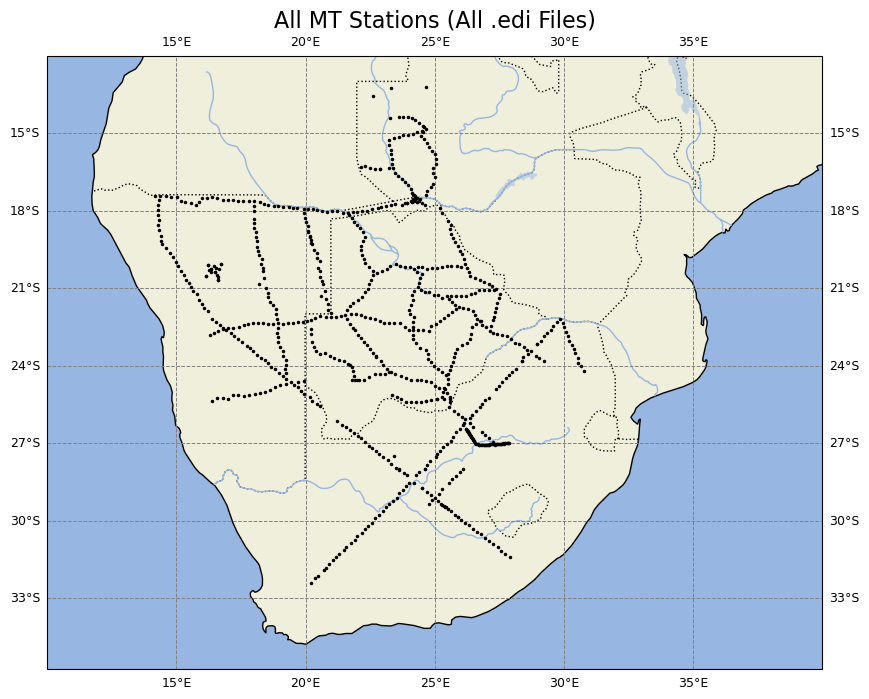

/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


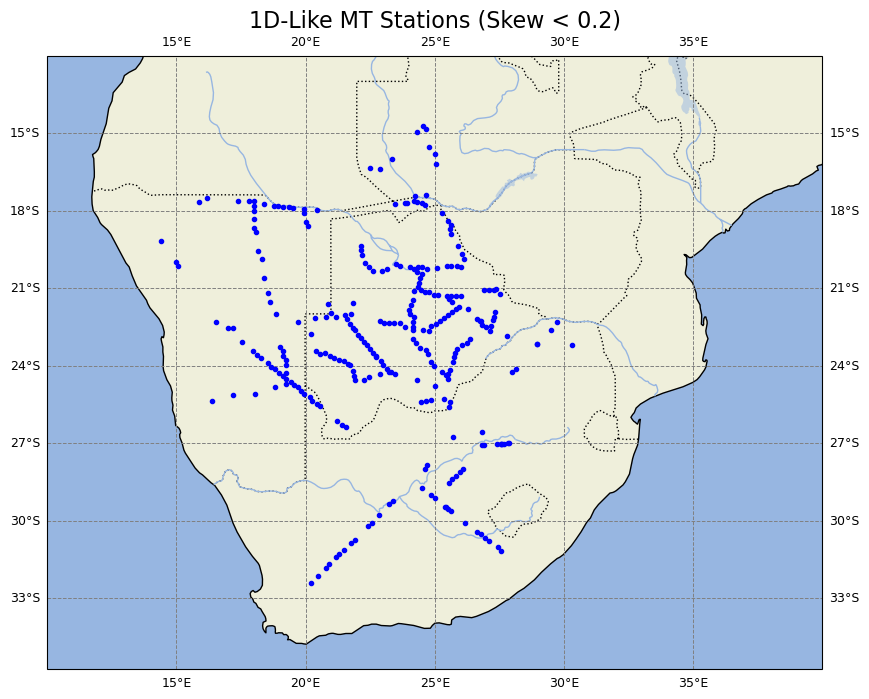

/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


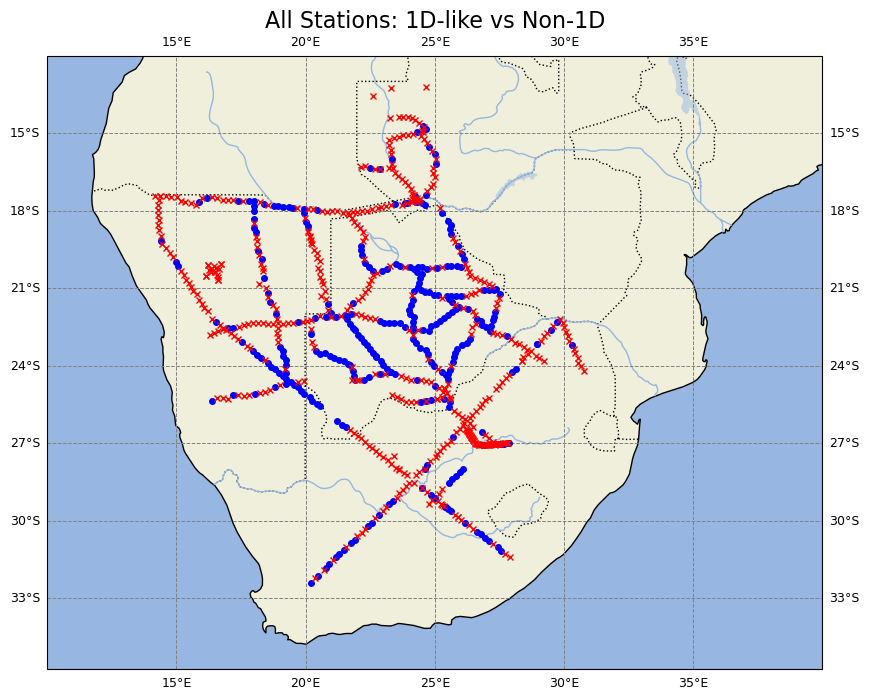

In [5]:
import re
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ----------------------------------------------------
# EXTRACT LAT / LONG FOR EACH STATION (EACH EDI FILE)
# ----------------------------------------------------
def extract_lat_lon(edi_path):

    def dms_to_dd(dms):
        try:
            sign = -1 if dms.strip().startswith("-") else 1
            parts = dms.replace("-", "").split(":")
            deg, minutes, seconds = map(float, parts)
            return sign * (deg + minutes/60 + seconds/3600)
        except:
            return np.nan

    lat, lon = np.nan, np.nan

    with open(edi_path, "r", errors="ignore") as f:
        for line in f:
            if line.strip().startswith("LAT="):
                lat = dms_to_dd(line.split("=")[1].strip())
            if line.strip().startswith("LONG="):
                lon = dms_to_dd(line.split("=")[1].strip())

    return lat, lon


# ----------------------------------------------------
# BUILD TABLE: station-level (each EDI file)
# ----------------------------------------------------
records_with_geo = []

for idx, row in df.iterrows():
    fname = row["File"]
    path = os.path.join(folder, fname)

    lat, lon = extract_lat_lon(path)
    records_with_geo.append((row["Site"], fname, row["Skew"], lat, lon))

geo_df = pd.DataFrame(records_with_geo,
                      columns=["Site", "File", "Skew", "Lat", "Lon"])

# classification
geo_df["Is1D"] = geo_df["Skew"] < 0.2

good_stations = geo_df[geo_df["Is1D"] == True]
bad_stations  = geo_df[geo_df["Is1D"] == False]


# ----------------------------------------------------
# MAP TEMPLATE FUNCTION
# ----------------------------------------------------
def setup_map(title):
    plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([10, 40, -35, -12])    # Southern Africa

    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAKES, alpha=0.5)
    ax.add_feature(cfeature.RIVERS)

    gl = ax.gridlines(draw_labels=True,
                      linewidth=0.7,
                      linestyle='--',
                      color='gray')

    gl.top_labels = True
    gl.bottom_labels = True
    gl.left_labels = True
    gl.right_labels = True

    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

    plt.title(title, fontsize=16)
    return ax


# ----------------------------------------------------
# IMAGE 1: ALL STATIONS (ALL .edi FILES)
# ----------------------------------------------------
ax = setup_map("All MT Stations (All .edi Files)")
for _, row in geo_df.iterrows():
    ax.plot(row["Lon"], row["Lat"],
            'k.', markersize=3,
            transform=ccrs.PlateCarree())
plt.show()


# ----------------------------------------------------
# IMAGE 2: ONLY 1D-LIKE STATIONS
# ----------------------------------------------------
ax = setup_map("1D-Like MT Stations (Skew < 0.2)")
for _, row in good_stations.iterrows():
    ax.plot(row["Lon"], row["Lat"],
            'bo', markersize=3,
            transform=ccrs.PlateCarree())
plt.show()


# ----------------------------------------------------
# IMAGE 3: ALL STATIONS, 1D VS NON-1D
# ----------------------------------------------------
ax = setup_map("All Stations: 1D-like vs Non-1D")

# Plot 1D-like (blue circles)
for _, row in good_stations.iterrows():
    ax.plot(row["Lon"], row["Lat"],
            marker='o',
            markersize=4,
            color='blue',
            transform=ccrs.PlateCarree())

# Plot non-1D (red crosses)
for _, row in bad_stations.iterrows():
    ax.plot(row["Lon"], row["Lat"],
            marker='x',
            markersize=5,
            color='red',
            transform=ccrs.PlateCarree())

plt.show()


/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


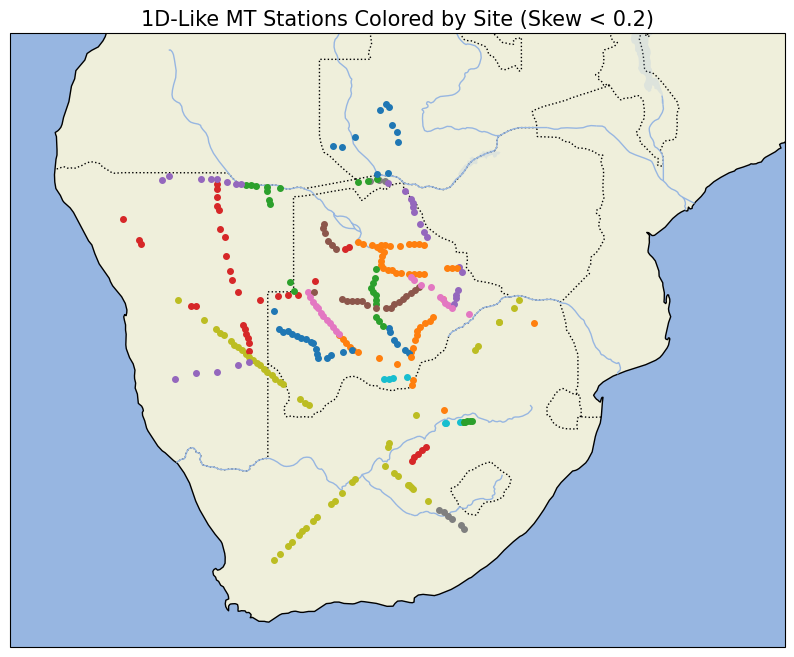


Color Name → Site Mapping:
Barotse Basin, Western Province, Zambia : tab:blue
Botswana, Africa : tab:orange
Central Botswana, Africa : tab:green
Coffiefontain, South Africa : tab:red
Hardap Region, Namibia, Africa : tab:purple
Kalahari Game Reserve, Botswana, Africa : tab:brown
Kang to Ghazi, Botswana, Africa : tab:pink
Kasane, Zimbabwe, Africa : tab:gray
Kimberley, South Africa : tab:olive
Klerksdorp, South Africa : tab:cyan
Kweneng, Botswana, Africa : tab:blue
Makgadikgadi Park, Botswana, Africa : tab:orange
NE Namibia, Africa : tab:green
Namibia, Africa : tab:red
Northern Namibia, Africa : tab:purple
Okavango Lake, Botswana, Africa : tab:brown
Orapa, Botswana, Africa : tab:pink
Smithfield, South Africa : tab:gray
South Africa : tab:olive
Southern Botswana, Africa : tab:cyan
Tshane, Botswana, Africa : tab:blue
Tzaneen, South Africa : tab:orange
Weiveld, South Africa : tab:green
Windhoek, Namibia, Africa : tab:red
Zimbabwe, Africa : tab:purple


In [6]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ----------------------------------------------------
# FILTER ONLY 1D-LIKE STATIONS
# ----------------------------------------------------
good_stations = geo_df[geo_df["Skew"] < 0.2].copy()
good_sites = sorted(good_stations["Site"].unique())

# ----------------------------------------------------
# USE DARK, HIGH-CONTRAST NAMED COLORS
# ----------------------------------------------------
named_colors = list(mcolors.TABLEAU_COLORS.keys())  
num_colors = len(named_colors)

repeat_factor = int(np.ceil(len(good_sites) / num_colors))
final_named_colors = (named_colors * repeat_factor)[:len(good_sites)]

site_color_map = dict(zip(good_sites, final_named_colors))

# convert names → actual color values for plotting
site_plot_color = {s: mcolors.TABLEAU_COLORS[c] for s, c in site_color_map.items()}

# ----------------------------------------------------
# PLOT MAP
# ----------------------------------------------------
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([10, 40, -35, -12])

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAKES, alpha=0.2)
ax.add_feature(cfeature.RIVERS)

# ----------------------------------------------------
# PLOT ALL STATIONS ONLY (NO CENTER HIGHLIGHT)
# ----------------------------------------------------
for _, row in good_stations.iterrows():
    site = row["Site"]
    color = site_plot_color[site]

    ax.plot(
        row["Lon"], row["Lat"],
        marker="o",
        markersize=4,
        color=color,
        transform=ccrs.PlateCarree(),
    )

plt.title("1D-Like MT Stations Colored by Site (Skew < 0.2)", fontsize=15)
plt.show()

# ----------------------------------------------------
# LEGEND PRINT
# ----------------------------------------------------
print("\nColor Name → Site Mapping:")
for site, color_name in site_color_map.items():
    print(f"{site} : {color_name}")
